# Characterization and Changing Nature of Aerosol Extreme Events over the U.S. Southwest

This code reproduces Figures 1 and 2 from the paper

By: Juliana Mejia Sepulveda
email: julianamejia@arizona.edu

## 1. Libraries

In [2]:
# LIBRARIES
import pandas as pd
import xarray as xr
import numpy as np
from scipy import interpolate

import os
from multiprocessing import Pool

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from matplotlib import cm
from matplotlib import colors
from datetime import datetime
import matplotlib.dates as mdates
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset



import matplotlib.font_manager as fm

import seaborn as sns

In [47]:
# Directory with the .xlsx files
basedir = '/home/u32/julianamejia/data/aeronet_data/Sites_2.0Level/'

# Function to read a single .xlsx file
def read_aeronet_file(file):
    if file.endswith('.lev20.xlsx'):  # Check if it is an .xlsx file
        # Extract the station name from the file name
        station_name = os.path.splitext(file)[0]  # This removes the .xlsx extension
        
        # Complete file path
        file_path = os.path.join(basedir, file)
        
        # Read the .xlsx file
        df = pd.read_excel(file_path, usecols=['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'AOD_1020nm', 
                                               'AOD_870nm', 'AOD_675nm', 'AOD_500nm', 
                                               'AOD_440nm', 'AOD_380nm', 'AOD_340nm'], engine='openpyxl')
        
        # Return the station name and the DataFrame
        return station_name, df
    return None  # If the file does not match the condition, return None

# Function to process files in parallel
def process_files_in_parallel():
    # Get the list of files in the directory
    files = os.listdir(basedir)
    
    # Create a pool of processes
    with Pool() as pool:
        # Process the files in parallel
        results = pool.map(read_aeronet_file, files)
    
    # Filter out None results
    results = [result for result in results if result is not None]
    
    # Dictionary to store the DataFrames with the station name as the key
    dataframes = {station_name: df for station_name, df in results}
    
    return dataframes

# Execute parallel file processing
dataframes = process_files_in_parallel()

# Access the data by station name
for station, df in dataframes.items():
    print(f"Aeronet Data {station}:")

Aeronet Data aeronet_UCSB.lev20:
Aeronet Data aeronet_La_Jolla.lev20:
Aeronet Data aeronet_Sevilleta.lev20:
Aeronet Data aeronet_TABLE_MOUNTAIN_CA.lev20:
Aeronet Data aeronet_Los_Alamos.lev20:
Aeronet Data aeronet_Maricopa.lev20:
Aeronet Data aeronet_Rogers_Dry_Lake.lev20:
Aeronet Data aeronet_Railroad_Valley.lev20:
Aeronet Data aeronet_Tucson.lev20:
Aeronet Data aeronet_MISR-JPL.lev20:
Aeronet Data aeronet_Monterey.lev20:


In [48]:
#Select the stations
tucson  = dataframes['aeronet_Tucson.lev20'].copy()
maricopa = dataframes['aeronet_Maricopa.lev20'].copy()

In [49]:
# First, convert the column to a date format correctly
tucson['Date(dd:mm:yyyy)'] = pd.to_datetime(tucson['Date(dd:mm:yyyy)'], format='%d:%m:%Y', errors='coerce')

# Check if there are any null values after the conversion
null_tucson = tucson['Date(dd:mm:yyyy)'].isnull().sum()

# If there are null values, print a warning message indicating the number of problematic values
if null_tucson > 0:
    print(f"Warning: {null_tucson} values could not be converted to dates due to format errors.")
    

    
# First, convert the column to a date format correctly
maricopa['Date(dd:mm:yyyy)'] = pd.to_datetime(maricopa['Date(dd:mm:yyyy)'], format='%d:%m:%Y', errors='coerce')

# Check if there are any null values after the conversion
null_maricopa = maricopa['Date(dd:mm:yyyy)'].isnull().sum()

# If there are null values, print a warning message indicating the number of problematic values
if null_maricopa > 0:
    print(f"Warning: {null_maricopa} values could not be converted to dates due to format errors.")

In [50]:
##TUCSON
# Make sure the date column is in datetime format (if it is not already)
tucson['Date(dd:mm:yyyy)'] = pd.to_datetime(tucson['Date(dd:mm:yyyy)'], format='%Y-%m-%d', errors='coerce')

# Combine the date and time columns
# First, concatenate the date and time columns into a single string
tucson['DateTime'] = tucson['Date(dd:mm:yyyy)'].astype(str) + ' ' + tucson['Time(hh:mm:ss)'].astype(str)

# Convert the new column to datetime format
tucson['DateTime'] = pd.to_datetime(tucson['DateTime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Optional: If you no longer need the original columns, you can drop them
tucson = tucson.drop(columns=['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)'])


##MARICOPA
# Make sure the date column is in datetime format (if it is not already)
maricopa['Date(dd:mm:yyyy)'] = pd.to_datetime(maricopa['Date(dd:mm:yyyy)'], format='%Y-%m-%d', errors='coerce')

# Combine the date and time columns
# First, concatenate the date and time columns into a single string
maricopa['DateTime'] = maricopa['Date(dd:mm:yyyy)'].astype(str) + ' ' + maricopa['Time(hh:mm:ss)'].astype(str)

# Convert the new column to datetime format
maricopa['DateTime'] = pd.to_datetime(maricopa['DateTime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Optional: If you no longer need the original columns, you can drop them
maricopa = maricopa.drop(columns=['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)'])

In [51]:
##TUCSON
# Set the 'DateTime' column as the DataFrame index
tucson = tucson.set_index('DateTime')
tucson.index = pd.to_datetime(tucson.index)


##MARICOPA
# Set the 'DateTime' column as the DataFrame index
maricopa = maricopa.set_index('DateTime')
maricopa.index = pd.to_datetime(maricopa.index)

In [52]:
##TUCSON
tucson = tucson.replace(-999, np.nan)

##MARICOPA
maricopa = maricopa.replace(-999, np.nan)

In [53]:
##TUCSON
tucson_daily = tucson.resample('1D', closed = 'right').mean()

##MARICOPA
maricopa_daily = maricopa.resample('1D', closed = 'right').mean()


## 2. Finding Aerosol Extreme Events

## 2.1 Finding AEEs using both intensity and duration

In [54]:
def group_extreme_events(df):
    df = df.copy()
    df['group'] = (df.index.to_series().diff().dt.days != 1).cumsum()
    grouped = df.groupby('group')

    result = grouped.agg({
        'AOD_500nm': ['mean', 'count','max'],
    })

    result.columns = ['AOD_mean', 'duration','AOD_max']
    result['start_date'] = grouped.apply(lambda g: g.index.min())
    result['end_date'] = grouped.apply(lambda g: g.index.max())
    result['all_dates'] = grouped.apply(lambda g: list(g.index.strftime('%Y-%m-%d')))
    result = result.set_index('start_date')

    return result

In [55]:
##TUCSON
tucson_extreme_mask = tucson_daily['AOD_500nm'] > tucson_daily['AOD_500nm'].quantile(0.90)
tucsondf_p90 = tucson_daily.loc[tucson_extreme_mask]
tucson_grouped = group_extreme_events(tucsondf_p90)

##MARICOPA
maricopa_extreme_mask = maricopa_daily['AOD_500nm'] > maricopa_daily['AOD_500nm'].quantile(0.90)
maricopadf_p90 = maricopa_daily.loc[maricopa_extreme_mask]
maricopa_grouped = group_extreme_events(maricopadf_p90)

In [56]:
# Sort and display the 10 longest events for each site
tucson_top_events = tucson_grouped.sort_values('duration', ascending=False)
maricopa_top_events = maricopa_grouped.sort_values('duration', ascending=False)

# results
print('Top 10 Longest Extreme AOD Events — Tucson')
tucson_top_events.head(10)

Top 10 Longest Extreme AOD Events — Tucson


,AOD_mean,duration,AOD_max,end_date,all_dates
start_date,,,,,
2000-07-25,0.225032,17,0.319785,2000-08-10,"[2000-07-25, 2000-07-26, 2000-07-27, 2000-07-2..."
2020-09-08,0.770936,15,2.795814,2020-09-22,"[2020-09-08, 2020-09-09, 2020-09-10, 2020-09-1..."
2020-08-17,0.375727,13,0.618759,2020-08-29,"[2020-08-17, 2020-08-18, 2020-08-19, 2020-08-2..."
2021-06-13,0.230353,12,0.467504,2021-06-24,"[2021-06-13, 2021-06-14, 2021-06-15, 2021-06-1..."
2017-09-01,0.254950,9,0.488767,2017-09-09,"[2017-09-01, 2017-09-02, 2017-09-03, 2017-09-0..."
2017-06-18,0.197748,9,0.277921,2017-06-26,"[2017-06-18, 2017-06-19, 2017-06-20, 2017-06-2..."
2003-08-11,0.178385,8,0.268745,2003-08-18,"[2003-08-11, 2003-08-12, 2003-08-13, 2003-08-1..."
2021-09-09,0.182156,8,0.253278,2021-09-16,"[2021-09-09, 2021-09-10, 2021-09-11, 2021-09-1..."
2012-06-29,0.199209,7,0.276299,2012-07-05,"[2012-06-29, 2012-06-30, 2012-07-01, 2012-07-0..."


## 2.2. Calculating number of AEEs per month per year

In [57]:
##TUCSON
# Filter the data to only include rows where AOD is above the threshold
tucson_above_threshold = tucson_daily[tucson_daily['AOD_500nm'] > tucson_p90['AOD_500nm']].copy()

# Extract year and month
tucson_above_threshold.loc[:, 'year'] = tucson_above_threshold.index.year
tucson_above_threshold.loc[:, 'month'] = tucson_above_threshold.index.month

# Count the number of days above the threshold per month and year
tucson_days_count = tucson_above_threshold.groupby(['year', 'month']).size()


##MARICOPA
# Filter the data to only include rows where AOD is above the threshold
maricopa_above_threshold = maricopa_daily[maricopa_daily['AOD_500nm'] > maricopa_p90['AOD_500nm']].copy()

# Extract year and month
maricopa_above_threshold.loc[:, 'year'] = maricopa_above_threshold.index.year
maricopa_above_threshold.loc[:, 'month'] = maricopa_above_threshold.index.month

# Count the number of days above the threshold per month and year
maricopa_days_count = maricopa_above_threshold.groupby(['year', 'month']).size()

In [58]:
##TUCSON
# Reset index and pivot to create a heatmap matrix
tucson_heatmap_data = tucson_days_count.unstack().fillna(0)
tucson_heatmap_data.index = tucson_heatmap_data.index.set_names(['Year'])
full_months = list(range(1, 13))

tucson_heatmap_data = tucson_heatmap_data.reindex(columns=full_months, fill_value=0)

##MARICOPA
# Reset index and pivot to create a heatmap matrix
maricopa_heatmap_data = maricopa_days_count.unstack().fillna(0)
maricopa_heatmap_data.index = maricopa_heatmap_data.index.set_names(['Year'])
full_months = list(range(1, 13))

maricopa_heatmap_data = maricopa_heatmap_data.reindex(columns=full_months, fill_value=0)

In [59]:
tucson_heatmap_data = tucson_heatmap_data.T
maricopa_heatmap_data = maricopa_heatmap_data.T

In [60]:
# Define month names manually
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Replace the index with month names
tucson_heatmap_data.index = month_names
maricopa_heatmap_data.index = month_names

In [61]:
tucson_heatmap_data

Year,1999,2000,2001,2003,2004,2005,2006,2009,2010,2011,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
January,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
February,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
March,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
April,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0
May,1.0,7.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,...,1.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
June,0.0,8.0,0.0,0.0,0.0,0.0,13.0,1.0,0.0,0.0,...,9.0,2.0,12.0,4.0,1.0,2.0,13.0,6.0,4.0,3.0
July,0.0,9.0,0.0,0.0,0.0,0.0,0.0,7.0,3.0,3.0,...,2.0,2.0,13.0,1.0,10.0,1.0,14.0,0.0,7.0,15.0
August,0.0,17.0,0.0,14.0,0.0,0.0,0.0,4.0,0.0,8.0,...,8.0,3.0,2.0,6.0,3.0,16.0,5.0,0.0,4.0,0.0
September,0.0,5.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,3.0,2.0,10.0,0.0,4.0,16.0,17.0,0.0,1.0,2.0
October,0.0,1.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0


## 3. Figure 1

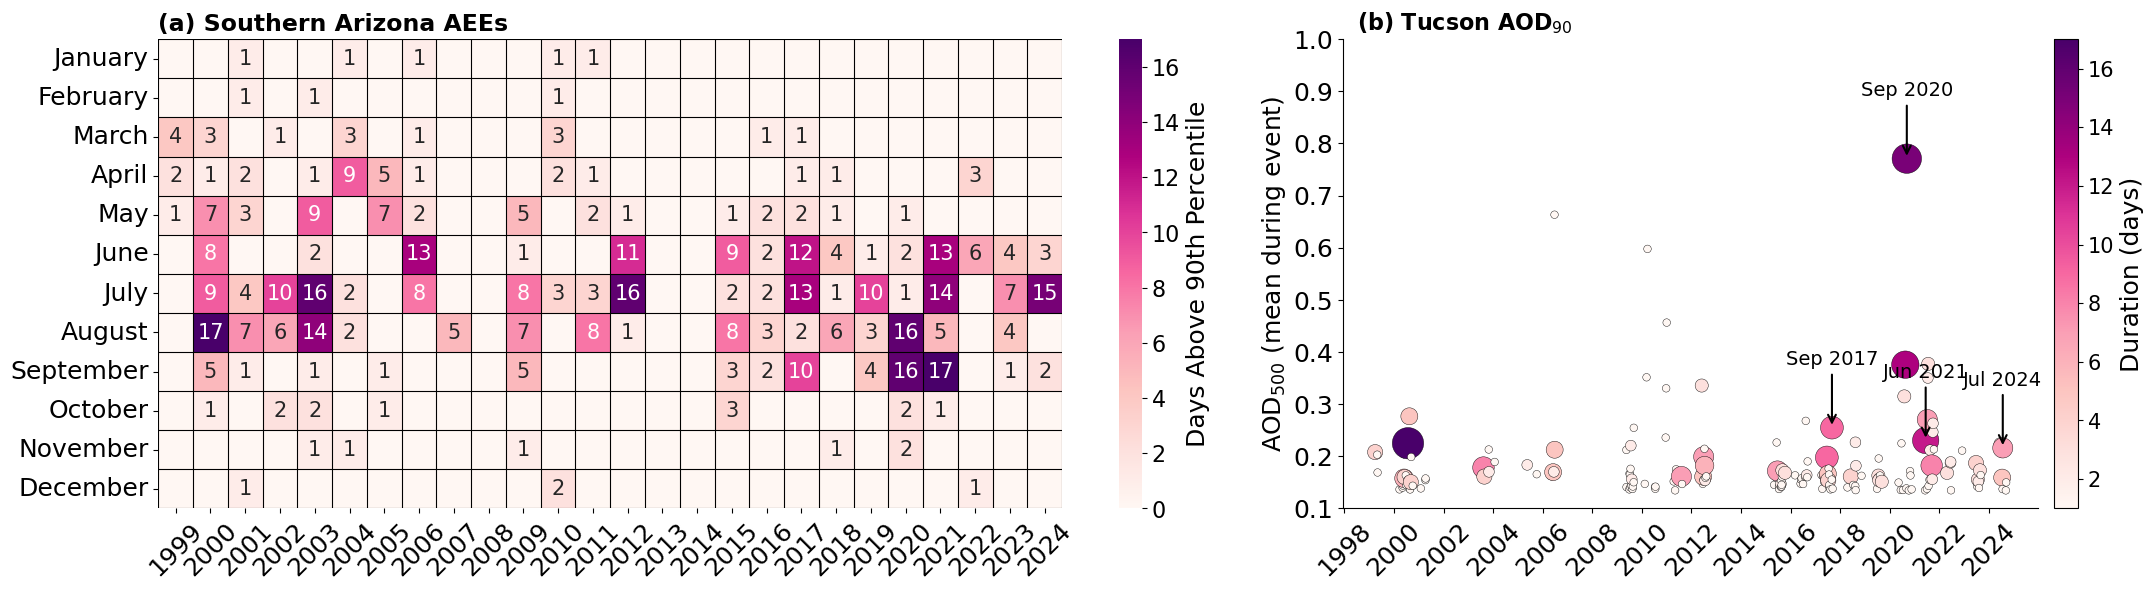

In [62]:
plt.close('all')

# ----------------------------
# 1. Build combined heatmap
# ----------------------------
t_union, m_union = tucson_heatmap_data.align(
    maricopa_heatmap_data, join='outer', axis=1
)

stacked = np.dstack([t_union.values, m_union.values])
combined_values = np.nanmax(stacked, axis=2)

combined_heatmap = pd.DataFrame(
    combined_values,
    index=t_union.index,
    columns=t_union.columns
)

# Extend heatmap to show full period
full_years = np.arange(1999, 2025)
combined_heatmap = combined_heatmap.reindex(columns=full_years, fill_value=0)

# Annotations
combined_annot = combined_heatmap.applymap(
    lambda x: f"{int(x)}" if x != 0 else ""
)

# Heatmap normalization
vmin = combined_heatmap.min().min()
vmax = combined_heatmap.max().max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# ----------------------------
# 2. Scatter normalization
# ----------------------------
dur_min = tucson_grouped['duration'].min()
dur_max = tucson_grouped['duration'].max()
norm_dur = mpl.colors.Normalize(vmin=dur_min, vmax=dur_max)

# ----------------------------
# 3. Create 1-row, 2-column figure
# ----------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(22, 6),
    gridspec_kw={'width_ratios': [1.35, 1]}
)

# ============================
# Panel (a): Heatmap
# ============================
sns.heatmap(
    combined_heatmap,
    cmap='RdPu',
    annot=combined_annot,
    fmt="",
    cbar=True,
    norm=norm,
    ax=ax1,
    lw=0.5,
    linecolor='black',
    annot_kws={"size": 15}
)

ax1.set_title('(a) Southern Arizona AEEs',
              fontsize=17, fontweight='bold', loc='left')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_xticklabels(combined_heatmap.columns, rotation=45, fontsize=18, color='black')
ax1.set_yticks(np.arange(len(combined_heatmap.index)) + 0.5)
ax1.set_yticklabels(combined_heatmap.index, rotation=0, fontsize=18, color='black')

# Grid lines
nrows, ncols = combined_heatmap.shape
ax1.hlines(np.arange(0, nrows + 1), *ax1.get_xlim(), colors='black', lw=0.8)
ax1.vlines(np.arange(0, ncols + 1), *ax1.get_ylim(), colors='black', lw=0.8)

# Heatmap colorbar
cbar1 = ax1.collections[0].colorbar
cbar1.set_label('Days Above 90th Percentile', fontsize=18)
cbar1.ax.tick_params(labelsize=16)

# ============================
# Panel (b): Scatter
# ============================
sc = ax2.scatter(
    tucson_grouped.index,
    tucson_grouped['AOD_mean'],
    s=tucson_grouped['duration'] * 30,
    c=tucson_grouped['duration'],
    cmap='RdPu',
    edgecolor='black',
    linewidth=0.3,
    norm=norm_dur
)

# Axes styling
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('black')
ax2.spines['bottom'].set_color('black')

ax2.tick_params(axis='both', which='both', colors='black', labelsize=18)
ax2.annotate('(b) Tucson AOD$_{90}$', xy=(0.02, 1.02), xycoords='axes fraction',
             fontsize=16, fontweight='bold', color='black')

ax2.set_ylim(0.1, 1)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.get_xticklabels(), rotation=45, ha='center')

ax2.set_ylabel('AOD$_{500}$ (mean during event)', fontsize=18, color='black')

# Highlight events
highlight_events = {
    "Sep 2017": (2017, 9),
    "Sep 2020": (2020, 9),
    "Jun 2021": (2021, 6),
    "Jul 2024": (2024, 7),
}

def find_event_point_by_month(df, year, month):
    """Return (x, y) for the longest-duration event in a given year-month."""
    subset = df[(df.index.year == year) & (df.index.month == month)]
    if subset.empty:
        print(f"No event found for {year}-{month:02d}")
        return None
    idx = subset['duration'].idxmax()
    return idx, subset.loc[idx, 'AOD_mean']

for label, (yr, mon) in highlight_events.items():
    result = find_event_point_by_month(tucson_grouped, yr, mon)
    if result:
        x, y = result
        ax2.annotate(
            label,
            xy=(x, y),
            xytext=(x, y + 0.12),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
            fontsize=14,
            color="black",
            ha="center",
        )

# Scatter colorbar
cbar2 = fig.colorbar(sc, ax=ax2, pad=0.02)
cbar2.set_label('Duration (days)', fontsize=18, color='black')
cbar2.ax.tick_params(labelsize=15)

plt.tight_layout()
plt.savefig('Figure1_Southern_AZ_Tucson_AEEs.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Regional AERONET Sites

In [63]:
# Create a dictionary with the renamed stations
selected_stations = {
    'tucson': dataframes['aeronet_Tucson.lev20'].copy(),
    'jolla': dataframes['aeronet_La_Jolla.lev20'].copy(),
    'sevilleta': dataframes['aeronet_Sevilleta.lev20'].copy(),
    'monterey': dataframes['aeronet_Monterey.lev20'].copy(),
    'alamos': dataframes['aeronet_Los_Alamos.lev20'].copy(),
    'railroad': dataframes['aeronet_Railroad_Valley.lev20'].copy(),
    'jpl': dataframes['aeronet_MISR-JPL.lev20'].copy(),
    'rogers': dataframes['aeronet_Rogers_Dry_Lake.lev20'].copy(),
    'ucsb': dataframes['aeronet_UCSB.lev20'].copy(),
    'mountain': dataframes['aeronet_TABLE_MOUNTAIN_CA.lev20'].copy(),
}

In [64]:
# Loop through each station to parse date and combine with time
for name, df in selected_stations.items():
    # 1. Convert 'Date(dd:mm:yyyy)' to datetime format (%d:%m:%Y)
    df['Date(dd:mm:yyyy)'] = pd.to_datetime(df['Date(dd:mm:yyyy)'], format='%d:%m:%Y', errors='coerce')
    null_date = df['Date(dd:mm:yyyy)'].isnull().sum()
    
    # 2. Combine date and time into a single DateTime string
    df['DateTime'] = df['Date(dd:mm:yyyy)'].astype(str) + ' ' + df['Time(hh:mm:ss)'].astype(str)
    
    # 3. Convert the combined string to proper datetime object
    df['DateTime'] = pd.to_datetime(df['DateTime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    null_datetime = df['DateTime'].isnull().sum()
    
    # 4. Drop original date and time columns
    df = df.drop(columns=['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)'])
    
    # 5. Print any warnings
    if null_date > 0 or null_datetime > 0:
        print(f"{name}: {null_date} invalid date(s), {null_datetime} invalid DateTime(s)")
    
    # 6. Store back the cleaned DataFrame
    selected_stations[name] = df

In [65]:
# Output dictionary
daily_means = {}

for name, df in selected_stations.items():
    # 1. Replace -999 with NaN
    df.replace(-999, np.nan, inplace=True)

    # 2. Set DateTime as index
    df = df.set_index('DateTime')

    # 3. Select only the AOD_550nm column
    aod = df[['AOD_500nm']]

    # 4. Resample to daily mean
    daily_mean = aod.resample('1D', closed='right').mean()

    # 5. Store results
    daily_means[name] = daily_mean

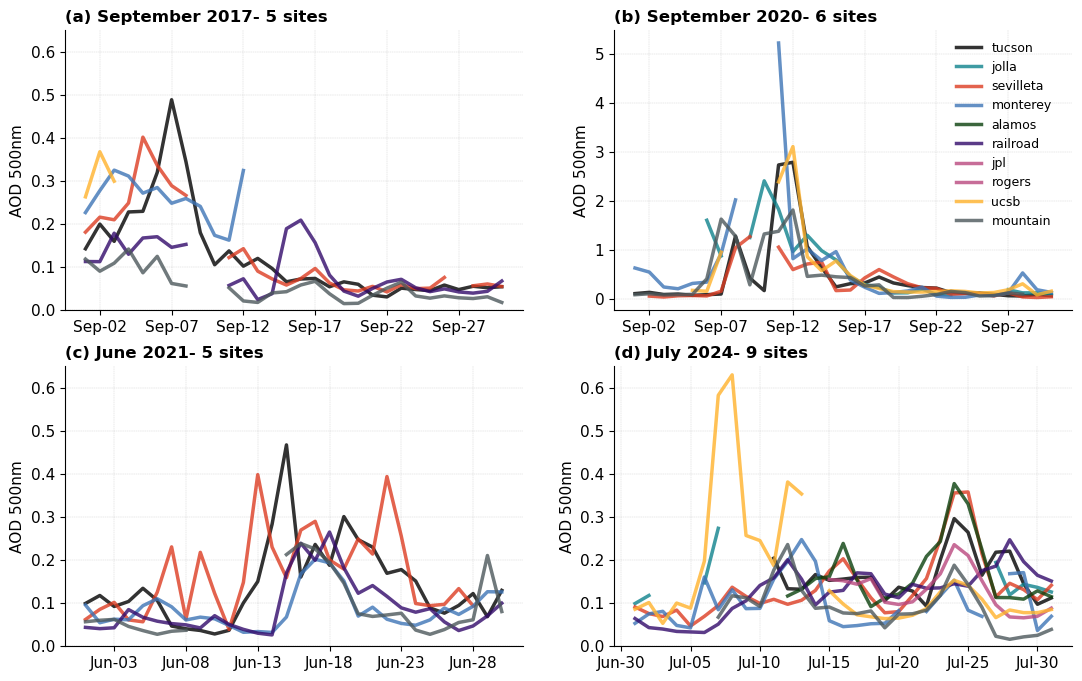

In [66]:
# Define the months you want to plot
event_months = [
    ('2017-09-01', '2017-09-30'),
    ('2020-09-01', '2020-09-30'),
    ('2021-06-01', '2021-06-30'),
    ('2024-07-01', '2024-07-31')
]

titles = [
    "(a) September 2017- 5 sites",
    "(b) September 2020- 6 sites",
    "(c) June 2021- 5 sites",
    "(d) July 2024- 9 sites"
]

# Create the figure and axes
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

colors = ['black','#0F828C','#DC3C22','#3D74B6','#0A400C','#320A6B','#BA487F','#BA487F','#FFB22C','#4C585B']

# Plot for each selected month
for i, (start_date, end_date) in enumerate(event_months):
    ax = axes[i]
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')

    for j, (station, df) in enumerate(daily_means.items()):  # j is station index
        mask = (df.index >= pd.to_datetime(start_date)) & (df.index <= pd.to_datetime(end_date))
        df_period = df.loc[mask]

        ax.plot(df_period.index, df_period['AOD_500nm'], label=station, alpha=0.8, color=colors[j], lw=2.5)
    
    ax.set_title(titles[i], fontsize = 12, loc = 'left', fontweight='bold')
    ax.set_ylabel('AOD 500nm', fontsize = 11)

    if i in [0, 2, 3]:
        ax.set_ylim(0, 0.65)
        
    ax.tick_params(labelsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.grid(color='gray', linestyle='--', linewidth=0.3, alpha = 0.4)
    
# Only add legend to the last subplot to avoid clutter
axes[1].legend(loc='upper right', bbox_to_anchor=(0.98, 1), fontsize = 9, frameon = False)


plt.savefig('Figure2_Extreme_Events_Southwest.png', dpi=200, bbox_inches='tight')
plt.show()